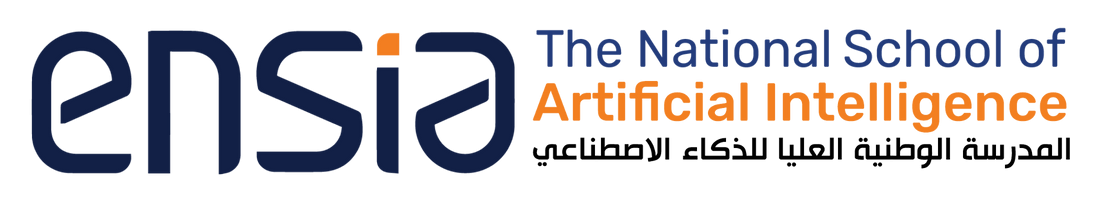

<div class="alert alert-block alert-warning">
<center>
    <h2>  The 3D Container Loading Optimizer </h2>
    <h4>A logic-based logistics tool that computes the optimal packing of 3D boxes into a standard shipping container to maximize volume utilization and stability, using Genetic Algorithms and Heuristic Search.</h4>
</center>
</div>

In [1]:
from __future__ import annotations
import heapq
import math
import random
import time
import json
from copy import deepcopy
from dataclasses import dataclass, field
from pathlib import Path
from typing import List, Tuple, Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

sns.set_theme(style="whitegrid")
print("All imports OK ✅")

All imports OK ✅


<div class="alert alert-block alert-warning">
<center>
    <h2> Core Classes </h2></center>
</div>

Container, Box, Space, SpaceManager, CLOProblem (container loading optimization problem)

In [2]:
@dataclass
class Box:
    """Represents a single box to be packed."""
    id: int
    length: float   # X dimension
    width: float    # Z dimension  (depth)
    height: float   # Y dimension  (vertical)
    weight_kg: float = 0.0
    fragile: bool = False

    @property
    def volume(self) -> float:
        return self.length * self.width * self.height

    def get_dimensions(self) -> Tuple[float, float, float]:
        return (self.length, self.width, self.height)

    def get_orientations(self) -> List[Tuple[float, float, float]]:
        """All valid (l, w, h) orientations respecting fragile constraint."""
        l, w, h = self.length, self.width, self.height
        if self.fragile:
            # height must stay as the vertical dimension — no tipping
            return list({(l, w, h), (w, l, h)})
        return list({
            (l, w, h), (l, h, w),
            (w, l, h), (w, h, l),
            (h, l, w), (h, w, l),
        })

    def __repr__(self):
        return (f"Box(id={self.id}, "
                f"{self.length}×{self.width}×{self.height}, "
                f"fragile={self.fragile})")

In [3]:
@dataclass
class Container:
    """Axis convention:  X=length, Z=width(depth), Y=height."""
    length: float   # X
    width: float    # Z
    height: float   # Y

    @property
    def volume(self) -> float:
        return self.length * self.width * self.height

    def get_dimensions(self) -> Tuple[float, float, float]:
        return (self.length, self.width, self.height)

    def __repr__(self):
        return f"Container({self.length}×{self.width}×{self.height} cm)"


In [4]:
@dataclass
class PlacedBox:
    """A box that has been successfully placed inside the container."""
    box: Box
    # Corner position (bottom-left-front)
    x: float   # along container length
    y: float   # along container height  (0 = floor)
    z: float   # along container width/depth
    # Actual dimensions used (after orientation selection)
    l: float   # size in X
    h: float   # size in Y
    w: float   # size in Z

    @property
    def volume(self) -> float:
        return self.l * self.h * self.w

    def overlaps(self, other: PlacedBox) -> bool:
        """True when two placed boxes share interior volume."""
        return not (
            self.x + self.l <= other.x or other.x + other.l <= self.x or
            self.y + self.h <= other.y or other.y + other.h <= self.y or
            self.z + self.w <= other.z or other.z + other.w <= self.z
        )

    def is_within(self, container: Container) -> bool:
        return (
            self.x >= 0 and self.x + self.l <= container.length and
            self.y >= 0 and self.y + self.h <= container.height and
            self.z >= 0 and self.z + self.w <= container.width
        )

    def __repr__(self):
        return (f"PlacedBox(id={self.box.id}, "
                f"pos=({self.x},{self.y},{self.z}), "
                f"dims={self.l}×{self.h}×{self.w})")

In [5]:

class Space:
    """
    A free rectangular region inside the container.

    Axis mapping (consistent with PlacedBox):
        x, l  →  container length  (X)
        y, h  →  container height  (Y, vertical)
        z, w  →  container width   (Z, depth)
    """

    def __init__(self, x: float, y: float, z: float,
                 l: float, h: float, w: float):
        self.x = x   # origin X
        self.y = y   # origin Y (floor level)
        self.z = z   # origin Z
        self.l = l   # extent in X
        self.h = h   # extent in Y (vertical)
        self.w = w   # extent in Z

    def volume(self) -> float:
        return self.l * self.h * self.w

    def try_fit(self, box: Box, strategy: str = "best"):
        """
        Try every valid orientation of *box* and return (True, (l,h,w)) for
        the orientation that fits best, or (False, None).

        strategy:
            "first"  — return the first fitting orientation (fast)
            "best"   — return the orientation that wastes the least space
        """
        best_dims  = None
        best_score = float("inf")

        for (bl, bw, bh) in box.get_orientations():
            # get_orientations returns (length, width, height) tuples;
            # map them to our space axes: l=X, h=Y(vert), w=Z
            for (sl, sh, sw) in _axis_permutations(bl, bw, bh):
                if sl <= self.l and sh <= self.h and sw <= self.w:
                    if strategy == "first":
                        return True, (sl, sh, sw)
                    score = (self.l - sl) + (self.h - sh) + (self.w - sw)
                    if score < best_score:
                        best_score = score
                        best_dims  = (sl, sh, sw)

        return (True, best_dims) if best_dims else (False, None)

    def split(self, l: float, h: float, w: float) -> List[Space]:
        """
        Guillotine split after placing a box of size (l, h, w) at the
        bottom-left-front corner of this space.

        Produces up to 3 non-overlapping sub-spaces:
            Right  — to the right  (+X) of the box
            Above  — directly above (+Y) the box footprint
            Behind — behind        (+Z) the box
        """
        new_spaces = []

        # Right of box (X remainder, full height & depth of space)
        if self.l - l > 0:
            new_spaces.append(Space(
                self.x + l, self.y, self.z,
                self.l - l, self.h, self.w
            ))

        # Above box (Y remainder, only over box footprint)
        if self.h - h > 0:
            new_spaces.append(Space(
                self.x, self.y + h, self.z,
                l, self.h - h, w
            ))

        # Behind box (Z remainder, box-width footprint, full Y of space)
        if self.w - w > 0:
            new_spaces.append(Space(
                self.x, self.y, self.z + w,
                l, self.h, self.w - w
            ))

        return new_spaces

    def __repr__(self):
        return (f"Space(pos=({self.x},{self.y},{self.z}) "
                f"size={self.l}×{self.h}×{self.w} "
                f"vol={self.volume():.0f})")


def _axis_permutations(bl: float, bw: float, bh: float
                       ) -> List[Tuple[float, float, float]]:
    """
    All distinct assignments of box dims (bl, bw, bh) onto space axes
    (l=X, h=Y, w=Z).  Returns list of (sl, sh, sw).
    """
    return list({
        (bl, bw, bh), (bl, bh, bw),
        (bw, bl, bh), (bw, bh, bl),
        (bh, bl, bw), (bh, bw, bl),
    })


In [6]:
class SpaceManager:
    """
    Tracks all free rectangular spaces inside the container and handles
    placement, guillotine splitting, and cleanup.
    """

    def __init__(self, container: Container):
        self.container = container
        self._reset_spaces()

    def _reset_spaces(self):
        c = self.container
        self.spaces: List[Space] = [Space(0, 0, 0, c.length, c.height, c.width)]
        self._packed_volume: float = 0.0

    def reset(self):
        """Reinitialise to an empty container (used between algorithm runs)."""
        self._reset_spaces()


    # Core placement API

    def find_placement(self, box: Box, strategy: str = "bottom"):
        """
        Find the best free space and orientation for *box*.

        strategy:
            "first"  — first space / orientation that fits
            "best"   — minimise leftover gap in chosen space
            "bottom" — lowest Y first (gravity), then left, then front
        Returns (space, dims) or (None, None).
        """
        best_space = None
        best_dims  = None
        best_score = None

        sorted_spaces = self._sorted_spaces(strategy)

        for space in sorted_spaces:
            fits, dims = space.try_fit(
                box,
                strategy="first" if strategy == "first" else "best"
            )
            if not fits:
                continue

            if strategy == "first":
                return space, dims

            sl, sh, sw = dims
            if strategy == "best":
                score = (space.l - sl) + (space.h - sh) + (space.w - sw)
            elif strategy == "bottom":
                # primary: lowest Y; secondary: leftmost X; tertiary: front Z
                score = (space.y * 1_000_000) + (space.x * 1_000) + space.z
            else:
                raise ValueError(f"Unknown strategy '{strategy}'")

            if best_score is None or score < best_score:
                best_score = score
                best_space = space
                best_dims  = dims

        return best_space, best_dims

    def place_box(self, box: Box, space: Space,
                  dims: Tuple[float, float, float]) -> Optional[PlacedBox]:
        """
        Place *box* in *space* using *dims* (l, h, w).
        Removes the space, adds sub-spaces from guillotine split,
        and returns a PlacedBox.  Returns None if space is gone.
        """
        if space not in self.spaces:
            return None

        l, h, w = dims
        placed = PlacedBox(
            box=box,
            x=space.x, y=space.y, z=space.z,
            l=l, h=h, w=w
        )

        self.spaces.remove(space)
        self.spaces.extend(space.split(l, h, w))
        self._clean_spaces()

        self._packed_volume += placed.volume
        return placed

    # Volume helpers
    @property
    def packed_volume(self) -> float:
        """Accumulated volume of successfully placed boxes."""
        return self._packed_volume

    def utilization(self) -> float:
        """Packing utilisation as a percentage."""
        cv = self.container.volume
        return (self._packed_volume / cv * 100.0) if cv else 0.0

    # Internal helpers
    def _sorted_spaces(self, strategy: str) -> List[Space]:
        if strategy == "bottom":
            return sorted(self.spaces, key=lambda s: (s.y, s.x, s.z))
        return self.spaces  # unsorted is fine for "first"/"best"

    def _clean_spaces(self):
        """Remove degenerate (zero-volume) and fully-dominated spaces."""
        valid = [s for s in self.spaces if s.l > 0 and s.h > 0 and s.w > 0]
        cleaned = []
        for s in valid:
            if not any(
                other is not s and self._contains(other, s)
                for other in valid
            ):
                cleaned.append(s)
        self.spaces = cleaned

    @staticmethod
    def _contains(a: Space, b: Space) -> bool:
        """True when space *a* fully contains space *b*."""
        return (
            a.x <= b.x and a.y <= b.y and a.z <= b.z and
            a.x + a.l >= b.x + b.l and
            a.y + a.h >= b.y + b.h and
            a.z + a.w >= b.z + b.w
        )

    def print_spaces(self):
        print(f"SpaceManager — {len(self.spaces)} free spaces "
              f"(container vol={self.container.volume:.0f}):")
        for s in sorted(self.spaces, key=lambda s: (s.y, s.x, s.z)):
            print(f"  {s}")


In [7]:
@dataclass
class PackingResult:
    """Stores the outcome of any packing algorithm."""
    algorithm: str
    container: Container
    placed_boxes: List[PlacedBox]
    packed_volume: float
    execution_time_ms: float

    def utilization(self) -> float:
        return (self.packed_volume / self.container.volume) * 100.0

    def to_json(self) -> dict:
        return {
            "algorithm": self.algorithm,
            "container": {
                "length": self.container.length,
                "width":  self.container.width,
                "height": self.container.height,
                "volume": self.container.volume,
            },
            "stats": {
                "boxes_placed":       len(self.placed_boxes),
                "packed_volume_cm3":  round(self.packed_volume, 2),
                "utilization_pct":    round(self.utilization(), 2),
                "execution_time_ms":  round(self.execution_time_ms, 2),
            },
            "placed_boxes": [
                {
                    "id": p.box.id,
                    "x": p.x, "y": p.y, "z": p.z,
                    "l": p.l, "h": p.h, "w": p.w,
                    "fragile": p.box.fragile,
                    "weight_kg": p.box.weight_kg,
                }
                for p in self.placed_boxes
            ],
        }

    def __repr__(self):
        return (f"PackingResult(algorithm={self.algorithm!r}, "
                f"utilization={self.utilization():.2f}%, "
                f"boxes={len(self.placed_boxes)}, "
                f"time={self.execution_time_ms:.1f}ms)")


In [8]:
@dataclass
class CLOProblem:
    """Container Loading Optimisation Problem instance."""
    container: Container
    seq_boxes: List[Box]

    def __post_init__(self):
        total_vol = 0.0
        for box in self.seq_boxes:
            total_vol += box.volume
            if not self._fits_in_container(box):
                raise ValueError(
                    f"Box {box} cannot fit in {self.container} "
                    f"in any orientation."
                )
        self._total_box_volume = total_vol
        if total_vol > self.container.volume:
            print(
                f"⚠️  Warning: total box volume ({total_vol:,.0f} cm³) "
                f"exceeds container volume ({self.container.volume:,.0f} cm³). "
                f"Not all boxes will fit."
            )

    def _fits_in_container(self, box: Box) -> bool:
        """True if at least one orientation of *box* fits in the container."""
        cd = sorted(self.container.get_dimensions())
        bd = sorted(box.get_dimensions())
        return all(bd[i] <= cd[i] for i in range(3))

    @property
    def total_box_volume(self) -> float:
        return self._total_box_volume

    @property
    def container_volume(self) -> float:
        return self.container.volume

    def get_difficulty(self) -> str:
        ratio = self.total_box_volume / self.container_volume
        if ratio < 0.5:
            return "Easy"
        elif ratio < 0.8:
            return "Medium"
        return "Hard"

    def __repr__(self):
        return (
            f"\n  Problem difficulty  : {self.get_difficulty()}"
            f"\n  Container           : {self.container.get_dimensions()}"
            f"\n  Number of boxes     : {len(self.seq_boxes)}"
            f"\n  Total box volume    : {self._total_box_volume:,.2f} cm³"
            f"\n  Container volume    : {self.container_volume:,.2f} cm³"
            f"\n  Theoretical fill    : "
            f"{self._total_box_volume / self.container_volume * 100:.1f}%"
        )

<div class="alert alert-block alert-warning">
<center>
    <h2> Data Loading & Processing </h2></center>
</div>

Dataset loaded: 301 rows
Rows after cleaning: 301  (removed 0)

=== Summary ===
       length   width  height  weight_kg  volume_cm3
count  301.00  301.00  301.00     301.00      301.00
mean    51.70   35.08   36.13      15.58    76159.87
std     27.37   16.20   20.88       9.83    81008.23
min     10.60   10.00    5.00       0.00     1080.00
25%     30.40   22.60   18.00       7.05    21528.00
50%     44.70   32.10   29.50      14.35    51392.64
75%     68.70   46.30   53.70      24.71   110858.29
max    118.60   79.00   79.60      30.00   654476.94

Fragile: 95 / 301
size_category
Large     253
Medium     48
Name: count, dtype: int64


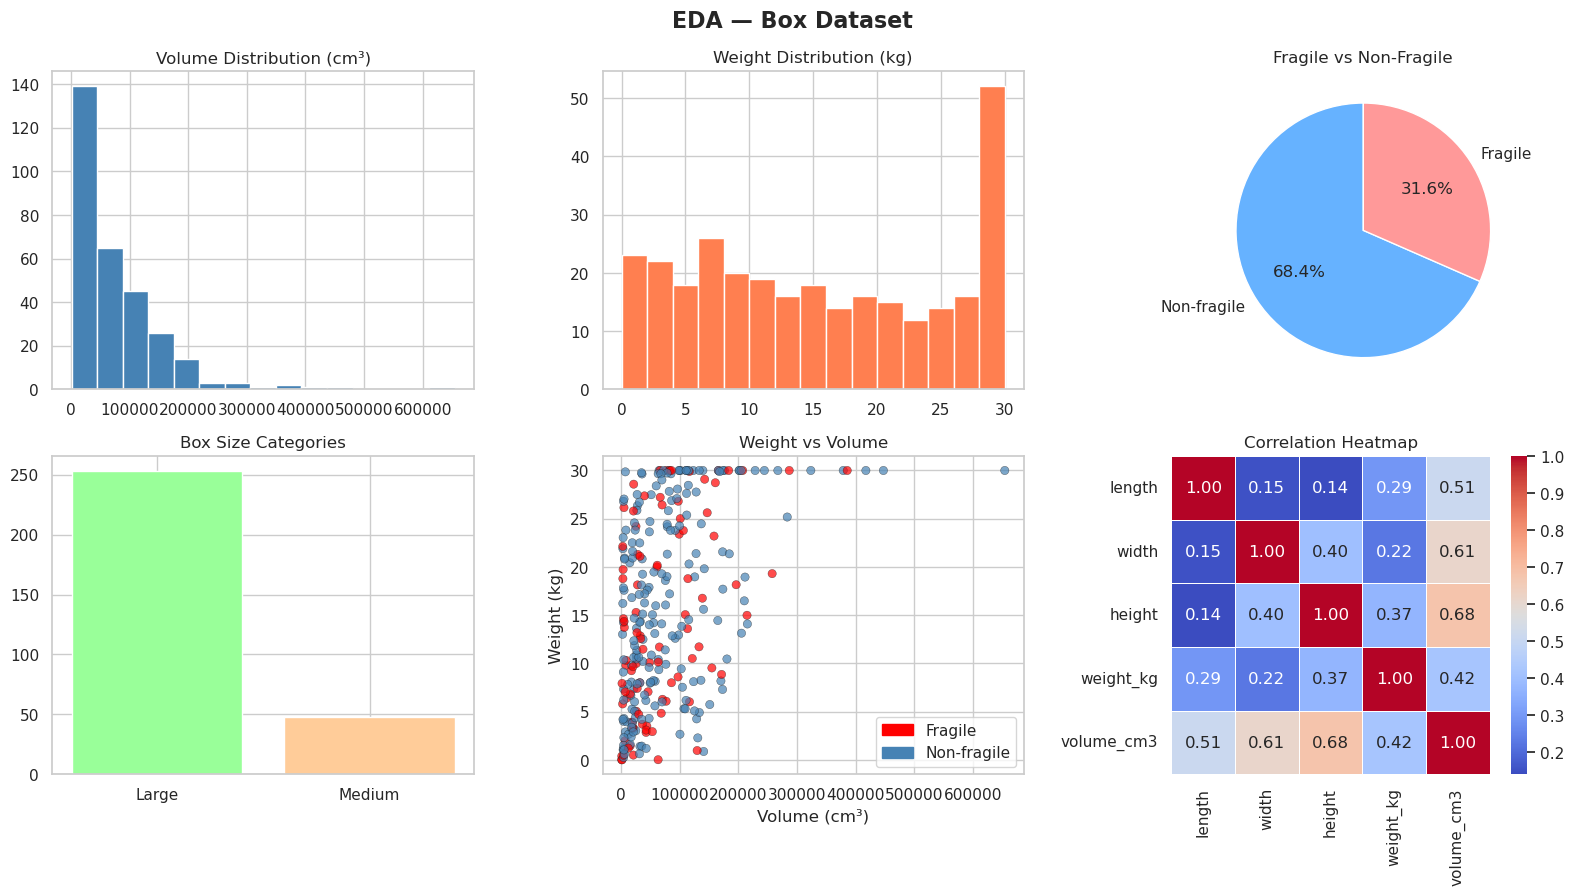

EDA plots saved ✅


In [9]:
DATA_PATH = Path("../data/boxes_trimmed(final dataset).csv")

df = pd.read_csv(DATA_PATH)
print(f"Dataset loaded: {len(df)} rows")

# ── Cleaning ────────────────────────────────────────────────
df["fragile"] = df["fragile"].astype(bool)
for col in ["length", "width", "height", "weight_kg"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

before = len(df)
df.dropna(subset=["length", "width", "height", "weight_kg"], inplace=True)
df = df[
    (df["length"] > 0) & (df["width"] > 0) &
    (df["height"] > 0) & (df["weight_kg"] >= 0)
]
df.reset_index(drop=True, inplace=True)
print(f"Rows after cleaning: {len(df)}  (removed {before - len(df)})")

# ── Feature engineering ─────────────────────────────────────
df["volume_cm3"] = df["length"] * df["width"] * df["height"]
df["density"]    = df["weight_kg"] / df["volume_cm3"]

def size_cat(v):
    if v < 1_000:   return "Small"
    if v < 10_000:  return "Medium"
    return "Large"

df["size_category"] = df["volume_cm3"].apply(size_cat)

print("\n=== Summary ===")
print(df[["length","width","height","weight_kg","volume_cm3"]].describe().round(2))
print(f"\nFragile: {df['fragile'].sum()} / {len(df)}")
print(df["size_category"].value_counts())
df.head(5)


# ── EDA plots ───────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle("EDA — Box Dataset", fontsize=16, fontweight="bold")

axes[0,0].hist(df["volume_cm3"], bins=15, color="steelblue", edgecolor="white")
axes[0,0].set_title("Volume Distribution (cm³)")

axes[0,1].hist(df["weight_kg"], bins=15, color="coral", edgecolor="white")
axes[0,1].set_title("Weight Distribution (kg)")

counts = df["fragile"].value_counts()
axes[0,2].pie(counts, labels=["Non-fragile","Fragile"], autopct="%1.1f%%",
              colors=["#66b2ff","#ff9999"], startangle=90)
axes[0,2].set_title("Fragile vs Non-Fragile")

sc = df["size_category"].value_counts()
axes[1,0].bar(sc.index, sc.values, color=["#99ff99","#ffcc99","#ff9999"])
axes[1,0].set_title("Box Size Categories")

col = df["fragile"].map({True:"red", False:"steelblue"})
axes[1,1].scatter(df["volume_cm3"], df["weight_kg"], c=col, alpha=0.7,
                  edgecolors="k", linewidths=0.3)
axes[1,1].set_title("Weight vs Volume")
axes[1,1].set_xlabel("Volume (cm³)")
axes[1,1].set_ylabel("Weight (kg)")
axes[1,1].legend(handles=[
    mpatches.Patch(color="red",      label="Fragile"),
    mpatches.Patch(color="steelblue",label="Non-fragile"),
])

corr = df[["length","width","height","weight_kg","volume_cm3"]].corr()
sns.heatmap(corr, ax=axes[1,2], annot=True, fmt=".2f", cmap="coolwarm",
            linewidths=0.5, square=True)
axes[1,2].set_title("Correlation Heatmap")

plt.tight_layout()
plt.savefig("eda_plots(final-dataset).png", dpi=150, bbox_inches="tight")
plt.show()
print("EDA plots saved ✅")


In [10]:
#We used this code to generate 240 more boxes, in file boxes_240_extended.csv
#no need to re-run it if ../data/boxes_360_extended.csv already exists

def generate_additional_boxes(existing_df, num_new=120, start_id=121):

    new_boxes = []
    
    # size ranges (length, width, height) from existing data
    size_ranges = [
        (10, 30, 10, 25, 10, 20),   
        (25, 50, 20, 40, 15, 35),     
        (40, 80, 30, 60, 25, 50),   
        (60, 110, 15, 40, 15, 30),  
        (30, 60, 30, 60, 40, 80),
    ]
    
    for i in range(num_new):
        size_type = random.choice(size_ranges)
        l_min, l_max, w_min, w_max, h_min, h_max = size_type
        
        length = round(random.uniform(l_min, l_max), 1)
        width = round(random.uniform(w_min, w_max), 1)
        height = round(random.uniform(h_min, h_max), 1)
        weight = round(random.uniform(0.5, 30), 2)
        fragile = random.random() < 0.3  
        
        new_boxes.append({
            'id': start_id + i,
            'length': length,
            'width': width,
            'height': height,
            'weight_kg': weight,
            'fragile': fragile,
        })
    
    df_new = pd.DataFrame(new_boxes)
    df_combined = pd.concat([existing_df, df_new], ignore_index=True)
    
    # calculating new volume
    total_vol = (df_combined['length'] * df_combined['width'] * df_combined['height']).sum()
    container_vol = 520 * 210 * 210
    print(f"Original boxes: {len(existing_df)}")
    print(f"New boxes: {num_new}")
    print(f"Total boxes: {len(df_combined)}")
    print(f"Total volume: {total_vol:,.0f} cm³")
    print(f"Utilization: {total_vol/container_vol*100:.1f}%")
    
    return df_combined

DATA_PATH = Path("../data/boxes_360_extended.csv")

if DATA_PATH.exists():
    print(f"File already exists! Loading from {DATA_PATH}")
    df_extended = pd.read_csv(DATA_PATH)
else:
    print(f"File not found. Generating new boxes...")
    df_extended = generate_additional_boxes(df, num_new=240, start_id=121)
    df_extended.to_csv(DATA_PATH, index=False)
    print(f"Generated and saved to {DATA_PATH}")

print(f"Loaded {len(df_extended)} boxes")

File already exists! Loading from ../data/boxes_360_extended.csv
Loaded 360 boxes


In [11]:
def trim_boxes_to_capacity(df, container_volume, volume_cols=['length', 'width', 'height']):
    """
    Remove boxes from the end until total volume <= container capacity.
    Maximizes utilization by keeping as many boxes as possible.
    
    Arguments:
        df: DataFrame with box dimensions
        container_volume: Total capacity of container
        volume_cols: Column names for dimensions
    
    Returns:
        df_trimmed: DataFrame with boxes removed from end
        utilization: Final utilization percentage
    """
    # Calculate volume for each box
    df = df.copy()
    df['volume'] = df[volume_cols[0]] * df[volume_cols[1]] * df[volume_cols[2]]
    
    # Calculate cumulative sum (from beginning)
    df['cumsum_volume'] = df['volume'].cumsum()
    
    # Find how many boxes fit within capacity
    valid_boxes = df[df['cumsum_volume'] <= container_volume]
    
    # Remove the cumulative sum column
    df_trimmed = valid_boxes.drop(columns=['volume', 'cumsum_volume'])
    
    # Calculate utilization
    total_volume = valid_boxes['volume'].sum()
    utilization = (total_volume / container_volume) * 100
    
    print(f"Original boxes: {len(df)}")
    print(f"Boxes after trimming: {len(df_trimmed)}")
    print(f"Total volume: {total_volume:.2f} / {container_volume:.2f}")
    print(f"Utilization: {utilization:.2f}%")
    print(f"Removed {len(df) - len(df_trimmed)} boxes from the end")
    
    return df_trimmed, utilization



In [12]:
CONTAINER_L = 520.0   # cm  (X)
CONTAINER_W = 210.0   # cm  (Z depth)
CONTAINER_H = 210.0   # cm  (Y height)

container = Container(length=CONTAINER_L, width=CONTAINER_W, height=CONTAINER_H)

df_extended = pd.read_csv('../data/boxes_360_extended.csv')
df_trimmed, utilization = trim_boxes_to_capacity(df_extended, container.volume)
# saving trimmed version
df_trimmed.to_csv('../data/boxes_trimmed.csv', index=False)

boxes: List[Box] = [
    Box(
        id=int(row["id"]),
        length=float(row["length"]),
        width=float(row["width"]),
        height=float(row["height"]),
        weight_kg=float(row["weight_kg"]),
        fragile=bool(row["fragile"]),
    )
    for _, row in df_trimmed.iterrows()
]

problem = CLOProblem(container=container, seq_boxes=boxes)
print(problem)


Original boxes: 360
Boxes after trimming: 301
Total volume: 22924121.68 / 22932000.00
Utilization: 99.97%
Removed 59 boxes from the end

  Problem difficulty  : Hard
  Container           : (520.0, 210.0, 210.0)
  Number of boxes     : 301
  Total box volume    : 22,924,121.68 cm³
  Container volume    : 22,932,000.00 cm³
  Theoretical fill    : 100.0%


In [13]:
total_box_volume = df['volume_cm3'].sum()
container_volume = container.volume
utilization = (total_box_volume / container_volume) * 100

print(f'Container volume      : {container_volume:,.0f} cm³  ({container_volume/1e6:.3f} m³)')
print(f'Total box volume      : {total_box_volume:,.0f} cm³  ({total_box_volume/1e6:.3f} m³)')
print(f'Raw utilization       : {utilization:.2f}%')
print(f'\n→ We have {len(boxes)} boxes to pack.')
print(f'→ Theoretical max utilization (ignoring gaps): {utilization:.1f}%')
print(f'→ Target after optimization: ≥ 75–80%')

Container volume      : 22,932,000 cm³  (22.932 m³)
Total box volume      : 22,924,122 cm³  (22.924 m³)
Raw utilization       : 99.97%

→ We have 301 boxes to pack.
→ Theoretical max utilization (ignoring gaps): 100.0%
→ Target after optimization: ≥ 75–80%


In [14]:
#df.to_csv('boxes_preprocessed.csv', index=False)
DATA_DIR = Path("../data")
df.to_csv(DATA_DIR / 'boxes_preprocessed.csv', index=False)
print('Saved boxes_preprocessed.csv ✅')
print(f'Final dataset shape: {df.shape}')
df.head()

Saved boxes_preprocessed.csv ✅
Final dataset shape: (301, 9)


,id,length,width,height,weight_kg,fragile,volume_cm3,density,size_category
0,1,62.0,17.0,60.0,0.020,True,63240.0,3.162555e-07,Large
1,2,15.0,12.0,6.0,0.015,True,1080.0,1.388889e-05,Medium
2,3,31.0,25.0,9.0,2.000,True,6975.0,2.867384e-04,Medium
3,4,61.0,43.0,8.0,0.500,True,20984.0,2.382768e-05,Large
4,5,58.0,39.0,38.0,8.000,True,85956.0,9.307087e-05,Large


In [15]:
# helper : decode a sequence --> PackingResult
def decode_sequence(
    sequence: List[Box],
    container: Container,
    strategy: str = "bottom",
    algorithm_name: str = "Decoder",
) -> PackingResult:
    """
    Pack *sequence* of boxes greedily into *container*.
    Returns a PackingResult.
    """
    sm = SpaceManager(container)
    placed: List[PlacedBox] = []

    for box in sequence:
        space, dims = sm.find_placement(box, strategy=strategy)
        if space and dims:
            pb = sm.place_box(box, space, dims)
            if pb:
                placed.append(pb)

    return PackingResult(
        algorithm=algorithm_name,
        container=container,
        placed_boxes=placed,
        packed_volume=sm.packed_volume,
        execution_time_ms=0.0,   # caller sets this
    )


<div class="alert alert-block alert-warning">
<center>
    <h2>  The Algorithms</h2>
</center>
</div>

## Greedy Heuristic (Best-Fit Decreasing)

#### Sort boxes by volume (largest first). Place each box in the first available space that fits.

##### Greedy algorithms are a class of algorithms that make locally optimal choices at each step with the hope of finding a global optimum solution.  

- At every step of the algorithm, we make a choice that looks the best at the moment.  

>>>> Placing the biggest box first  

- To make the choice, we sometimes sort the array so that we can always get the next optimal choice quickly.  

>>>> Sorting the boxes depending on the volume from biggest to smallest

- After making a choice, we check for constraints (if there are any) and keep picking until we find the solution.  
Greedy algorithms do not always give the best solution.  

<div class="alert alert-block alert-info"> 
<b>We used a priority queue to get the next optimal item.</b>
</div>

In [16]:
class GreedyPacker:
    """
    Sort boxes by volume descending (max-heap) and place each one using
    the 'bottom' (gravity-aware) strategy.
    """

    def pack(self, problem: CLOProblem) -> PackingResult:
        t0 = time.time()

        # Build a max-heap keyed on -volume so the largest box pops first
        heap: List[Tuple[float, int, Box]] = [
            (-box.volume, box.id, box) for box in problem.seq_boxes
        ]
        heapq.heapify(heap)

        sm = SpaceManager(problem.container)
        placed: List[PlacedBox] = []

        while heap:
            _, _, box = heapq.heappop(heap)
            space, dims = sm.find_placement(box, strategy="bottom")
            if space and dims:
                pb = sm.place_box(box, space, dims)
                if pb:
                    placed.append(pb)

        return PackingResult(
            algorithm="Greedy Best-Fit Decreasing",
            container=problem.container,
            placed_boxes=placed,
            packed_volume=sm.packed_volume,
            execution_time_ms=(time.time() - t0) * 1000,
        )


As the greedy packer is fast, we suggest to test it with distinct heuristics, than pick the best.
The additional heuristics we choose: 
- Max Dimensions: Long/narrow items (pipes, planks, posters) that need to be aligned with container walls.  
- Area: big footprint to be placed first, ssince small one can fill the gaps.  
- Perimiter: favors boxes that are neither too flat nor too tall.  
- Surface Area: boxes with larger surface area have more contact with other boxes, making them more stable.  
- Volume * Density: maintains stability (heavy+large boxes at bottom, light+small at top).  
- Min Dimension First: boxes with larger smallest dimension go first (more cube-like). Very flat or very narrow boxes go last (can fill gaps)
- Original order: if user has already sort them efficiently according to some other feature.

In [17]:
class SmartGreedyPacker:
    """
    Tries multiple greedy strategies and returns the best packing.
    """
    
    def __init__(self):
        self.strategies = [
            ("Volume (largest first)", lambda b: b.volume),
            ("Max dimension", lambda b: max(b.length, b.width, b.height)),
            ("Area", lambda b: b.length * b.width),  
            ("Perimeter", lambda b: b.length + b.width + b.height),     
            ("Surface area", lambda b: 2*(b.length*b.width + b.length*b.height + b.width*b.height)),
            ("Volume * Density", lambda b: b.volume * b.weight_kg),
            ("Min dimension first (small boxes last)", lambda b: -min(b.length, b.width, b.height)),
        ]
        self.strategies.insert(0, ("Original dataset order", None))
    
    def pack(self, problem: CLOProblem) -> PackingResult:
        best_result = None
        best_util = 0
        T={}
        
        for strategy_name, key_func in self.strategies:
            t0 = time.time()
            print(f"  Trying strategy: {strategy_name} ...")
            if key_func is None:
                sorted_boxes = problem.seq_boxes[:]  # original order
            else:
                sorted_boxes = sorted(problem.seq_boxes, key=key_func, reverse=True)
            
            sm = SpaceManager(problem.container)
            placed: List[PlacedBox] = []
            for box in sorted_boxes:
                space, dims = sm.find_placement(box, strategy="bottom")
                if space and dims:
                    pb=sm.place_box(box, space, dims)
                    if pb:
                        placed.append(pb)
            
            util = sm.utilization()
            print(f"    Utilization: {util:.2f}%")
            
            if util > best_util:
                best_util = util
                best_sm = sm
                best_strategy = strategy_name
            
            T[strategy_name]=(time.time() - t0) * 1000
        
        print(f"\nBest strategy: {best_strategy} with {best_util:.2f}% utilization")
        
        return PackingResult(
            algorithm=f"Multi-Strategy Greedy ({best_strategy})",
            container=problem.container,
            placed_boxes=placed,
            packed_volume=best_sm.packed_volume,
            execution_time_ms=T[best_strategy] 
        )

## Genetic Algorithm (GA)
- Chromosome: A permutation (sequence) of boxes to pack.  
- Decoder (Heuristic): Take the sequence from the GA and place each box using a "Best Fit" logic.  
- Fitness: The total volume packed.

In [18]:
class GAPacker:
    """
    Optimized Genetic Algorithm starting from Smart Greedy solution.
    Interactive: asks user if they want to continue when exceeding target.
    """
    
    def __init__(
        self,
        pop_size:       int   = 30,
        generations:    int   = 50,
        crossover_prob: float = 0.85,
        mutation_prob:  float = 0.20,
        tournament_k:   int   = 3,
        elitism:        int   = 3,
        strategy:       str   = "bottom",
        target_pct:     float = 75.0, 
        interactive:    bool  = True,
        seed:           Optional[int] = 42,
    ):
        self.pop_size = pop_size
        self.generations = generations
        self.crossover_prob = crossover_prob
        self.mutation_prob = mutation_prob
        self.tournament_k = tournament_k
        self.elitism = elitism
        self.strategy = strategy
        self.target_pct = target_pct
        self.interactive = interactive
        self._cache = {}
        if seed is not None:
            random.seed(seed)
            np.random.seed(seed)
    
    def _evaluate(self, chromosome: List[Box], container: Container) -> float:
        """Evaluate fitness with caching."""
        key = tuple(b.id for b in chromosome)
        if key in self._cache:
            return self._cache[key]
        
        sm = SpaceManager(container)
        for box in chromosome:
            space, dims = sm.find_placement(box, strategy=self.strategy)
            if space and dims:
                sm.place_box(box, space, dims)
        
        volume = sm.packed_volume
        self._cache[key] = volume
        return volume
    
    def _greedy_sequence(self, boxes: List[Box], container: Container, key_func=None) -> List[Box]:
        """Generate a greedy solution with given sorting key."""
        if key_func is None:
            sorted_boxes = boxes[:]
        else:
            sorted_boxes = sorted(boxes, key=key_func, reverse=True)
        
        sm = SpaceManager(container)
        placed = []
        for box in sorted_boxes:
            space, dims = sm.find_placement(box, strategy=self.strategy)
            if space and dims:
                placed.append(box)
        
        placed_ids = {b.id for b in placed}
        unplaced = [b for b in boxes if b.id not in placed_ids]
        return placed + unplaced
    
    def _smart_initial_population(self, boxes: List[Box], container: Container, smart_sequence: List[Box]) -> List[List[Box]]:
        """Create initial population with diverse strategies + smart greedy result."""
        population = []
        
        # 1. Smart Greedy result (starting point!)
        if smart_sequence:
            population.append(smart_sequence)
            print(f"Added Smart Greedy solution ({self._evaluate(smart_sequence, container) / container.volume * 100:.1f}%)")
        
        # 2. Volume descending
        vol_seq = self._greedy_sequence(boxes, container, lambda b: b.volume)
        population.append(vol_seq)
        
        # 3. Surface area descending
        area_seq = self._greedy_sequence(boxes, container, lambda b: 2*(b.length*b.width + b.length*b.height + b.width*b.height))
        population.append(area_seq)
        
        # 4. Max dimension descending
        maxdim_seq = self._greedy_sequence(boxes, container, lambda b: max(b.length, b.width, b.height))
        population.append(maxdim_seq)
        
        # 5. Volume * Density (heavy items first for stability)
        heavy_seq = self._greedy_sequence(boxes, container, lambda b: b.volume * b.weight_kg if b.weight_kg > 0 else b.volume)
        population.append(heavy_seq)
        
        # 6. Random permutations (fill remaining)
        remaining = self.pop_size - len(population)
        for _ in range(remaining):
            shuffled = boxes[:]
            random.shuffle(shuffled)
            population.append(shuffled)
        
        return population[:self.pop_size]
    
    @staticmethod
    def _pmx(parent_a: List[Box], parent_b: List[Box]) -> Tuple[List[Box], List[Box]]:
        """Partially Mapped Crossover."""
        n = len(parent_a)
        
        # Random crossover points
        cx1, cx2 = sorted(random.sample(range(n), 2))
        
        # creating mapping from box ID to position
        pos_a = {box.id: i for i, box in enumerate(parent_a)}
        pos_b = {box.id: i for i, box in enumerate(parent_b)}
        
        # initializing children
        child1 = parent_a[:]
        child2 = parent_b[:]
        
        # swapping segments
        for i in range(cx1, cx2 + 1):
            box1, box2 = child1[i], child2[i]
            if box1.id != box2.id:
                pos1 = pos_a[box2.id]
                pos2 = pos_b[box1.id]
                child1[i], child1[pos1] = child1[pos1], child1[i]
                child2[i], child2[pos2] = child2[pos2], child2[i]
        
        return child1, child2
    
    def _tournament_select(self, population: List[List[Box]], fitnesses: List[float]) -> List[Box]:
        candidates = random.sample(list(zip(population, fitnesses)), self.tournament_k)
        best = max(candidates, key=lambda x: x[1])[0]
        return best[:]
    
    def _mutate(self, chromosome: List[Box]) -> List[Box]:
        mutant = chromosome[:]
        if random.random() < 0.5:
            # swapping mutation
            i, j = random.sample(range(len(mutant)), 2)
            mutant[i], mutant[j] = mutant[j], mutant[i]
        else:
            # scrambling mutation
            i, j = sorted(random.sample(range(len(mutant)), 2))
            segment = mutant[i:j+1]
            random.shuffle(segment)
            mutant[i:j+1] = segment
        return mutant
    
    def _ask_continue(self, current_util: float, generation: int) -> bool:
        """Ask user if they want to continue optimization."""
        print(f"\n Reached {self.target_pct:.0f}% target at generation {generation}!")
        print(f"   Current utilization: {current_util:.1f}%")
        
        while True:
            response = input("   Continue searching for better solution? (y/n): ").lower().strip()
            if response in ['y', 'yes']:
                print("   Continuing optimization...\n")
                return True
            elif response in ['n', 'no']:
                print(f"   Stopping at {current_util:.1f}% utilization.\n")
                return False
            else:
                print("   Please enter 'y' or 'n'")
    
    def pack(self, problem: CLOProblem, smart_sequence: List[Box] = None) -> PackingResult:
        t0 = time.time()
        container = problem.container
        boxes = problem.seq_boxes
        target_volume = container.volume * (self.target_pct / 100.0)
        
        print(f"  Creating initial population ({self.pop_size} individuals)...")
        population = self._smart_initial_population(boxes, container, smart_sequence)
        
        # evaluating initial fitness
        fitnesses = [self._evaluate(chrom, container) for chrom in population]
        
        best_chromosome = population[np.argmax(fitnesses)][:]
        best_fitness = max(fitnesses)
        best_util = best_fitness / container.volume * 100
        
        print(f"  Initial best: {best_util:.1f}% utilization")
        
        history = []
        no_improvement = 0
        target_reached = False
        
        for gen in range(self.generations):
            new_population = []
            
            # elitism
            elite_idx = np.argsort(fitnesses)[-self.elitism:][::-1]
            for idx in elite_idx:
                new_population.append(population[idx][:])
            
            # generating offspring
            while len(new_population) < self.pop_size:
                p1 = self._tournament_select(population, fitnesses)
                p2 = self._tournament_select(population, fitnesses)
                
                if random.random() < self.crossover_prob:
                    c1, c2 = self._pmx(p1, p2)
                else:
                    c1, c2 = p1[:], p2[:]
                
                # Adaptive mutation
                mut_rate = self.mutation_prob * (1 - gen / self.generations * 0.5)
                if random.random() < mut_rate:
                    c1 = self._mutate(c1)
                if random.random() < mut_rate:
                    c2 = self._mutate(c2)
                
                new_population.extend([c1, c2])
            
            population = new_population[:self.pop_size]
            fitnesses = [self._evaluate(chrom, container) for chrom in population]
            
            # tracking the best
            gen_best_idx = np.argmax(fitnesses)
            if fitnesses[gen_best_idx] > best_fitness:
                best_fitness = fitnesses[gen_best_idx]
                best_chromosome = population[gen_best_idx][:]
                best_util = best_fitness / container.volume * 100
                no_improvement = 0
                print(f"  Gen {gen+1}: improved to {best_util:.1f}%")
                
                # Check if we hit target and ask user
                if not target_reached and best_fitness >= target_volume:
                    target_reached = True
                    if self.interactive:
                        should_continue = self._ask_continue(best_util, gen+1)
                        if not should_continue:
                            print(f"Stopping early at user request (gen {gen+1})")
                            break
                    else:
                        print(f"Reached {self.target_pct:.0f}% target at generation {gen+1}")
            else:
                no_improvement += 1
            
            history.append((gen, best_util))
            
            # early stopping: no improvement for 10 generations
            if no_improvement >= 10:
                print(f" Early stopping: no improvement for {no_improvement} generations")
                break
        
        print(f"  Final best: {best_util:.1f}% utilization")
        
        result = decode_sequence(
            best_chromosome, container,
            strategy=self.strategy,
            algorithm_name="Genetic Algorithm",
        )
        result.execution_time_ms = (time.time() - t0) * 1000
        
        # plotting convergence
        if history:
            gens, utils = zip(*history)
            plt.figure(figsize=(8, 4))
            plt.plot(gens, utils, color="#55A868", linewidth=2)
            plt.axhline(y=self.target_pct, color='red', linestyle='--', linewidth=1, label=f'Target {self.target_pct}%')
            plt.xlabel("Generation")
            plt.ylabel("Best Utilisation (%)")
            plt.title("GA — Convergence (Starting from Smart Greedy)")
            plt.legend()
            plt.grid(True, alpha=0.3)
            plt.tight_layout()
            plt.savefig("ga_convergence.png", dpi=120)
            plt.show()
        
        return result

## Simulated Annealing

### What is Simulated Annealing?

Imagine you're trying to find the lowest point in a hilly landscape — blindfolded.  
A simple strategy: always step downhill. But this gets you **stuck in small valleys** (local optima).  

Simulated Annealing's strategy: **sometimes take a step uphill on purpose**, especially early on.  
As time goes on, you take fewer and fewer uphill steps until you only go downhill.  
This way you **escape local optima** and find a much better valley (global optimum).  

The name comes from **metallurgy**: when you heat metal and let it cool slowly,  
atoms settle into a strong, low-energy structure. Fast cooling = weak metal. Slow cooling = strong metal.  
We do the same with our solution.  

---
### How it works in our project:

1. Start with a random order (sequence) of boxes
2. Pack them into the container using a heuristic → measure how full it is (**fitness**)
3. **Perturb**: randomly swap two boxes in the sequence
4. Pack again → measure new fitness
5. If new is better → accept it
6. If new is worse → **maybe accept it anyway** (based on temperature)
7. Slowly lower the temperature → repeat thousands of times
8. Return the best solution found

In [19]:
class SAPacker:
    def __init__(
        self,
        T_init:     float = 500.0,
        alpha:      float = 0.99,
        iterations: int   = 500,
        strategy:   str   = "bottom",
        target_pct_of_max: float = 75.0,
        interactive: bool = True,
        seed:       Optional[int] = 42,
    ):
        self.T_init     = T_init
        self.alpha      = alpha
        self.iterations = iterations
        self.strategy   = strategy
        self.target_pct_of_max = target_pct_of_max
        self.interactive = interactive
        self._cache = {}
        if seed is not None:
            random.seed(seed)

    def _evaluate(self, seq: List[Box], container: Container) -> float:
        key = tuple(b.id for b in seq)
        if key in self._cache:
            return self._cache[key]  
        sm = SpaceManager(container)
        for box in seq:
            space, dims = sm.find_placement(box, strategy=self.strategy)
            if space and dims:
                sm.place_box(box, space, dims)
        self._cache[key] = sm.packed_volume
        return sm.packed_volume

    @staticmethod
    def _swap(seq: List[Box]) -> List[Box]:
        new_seq = seq[:]
        i, j = random.sample(range(len(new_seq)), 2)
        new_seq[i], new_seq[j] = new_seq[j], new_seq[i]
        return new_seq

    def _ask_continue(self, current_util: float, pct_of_max: float, iteration: int) -> bool:
        """Ask user if they want to continue optimization."""
        print(f"\n Reached target {self.target_pct_of_max:.0f}% of theoretical max at iteration {iteration}!")
        print(f"  Current: {pct_of_max:.1f}% of theoretical max ({current_util:.1f}% of container)")
        
        while True:
            response = input("Continue searching for better solution? (y/n): ").lower().strip()
            if response in ['y', 'yes']:
                print("     Continuing optimization...\n")
                return True
            elif response in ['n', 'no']:
                print(f"     Stopping at {pct_of_max:.1f}% of theoretical max.\n")
                return False
            else:
                print("     Please enter 'y' or 'n'")

    def pack(self, problem: CLOProblem) -> PackingResult:
        t0 = time.time()
        theoretical_max_volume = problem.total_box_volume 
        container_vol = problem.container.volume
        
        theoretical_max_util = theoretical_max_volume / container_vol * 100
        
        target_volume = theoretical_max_volume * (self.target_pct_of_max / 100.0)
        target_util = target_volume / container_vol * 100

        current_seq = sorted(problem.seq_boxes, key=lambda b: b.volume, reverse=True)
        current_score = self._evaluate(current_seq, problem.container)

        best_seq = current_seq[:]
        best_score = current_score
        
        print(f"  Theoretical max: {theoretical_max_util:.1f}% of container")
        print(f"  Target: {self.target_pct_of_max:.0f}% of theoretical max = {target_util:.1f}% of container")
        print(f"  Initial: {best_score/container_vol*100:.1f}% of container")

        no_improvement_count = 0
        T = self.T_init
        history = []
        target_reached = False  # for tracking if we have reached success criteria which is >=75-80%

        for iteration in range(self.iterations):
            current_container_util = best_score / container_vol * 100
            current_pct_of_max = best_score / theoretical_max_volume * 100
            
            # checking if target reached
            if not target_reached and best_score >= target_volume:
                target_reached = True
                if self.interactive:
                    should_continue = self._ask_continue(current_container_util, current_pct_of_max, iteration)
                    if not should_continue:
                        break
                else:
                    print(f"Reached {self.target_pct_of_max:.0f}% of theoretical max at iteration {iteration} - stopping")
                    break
            
            # stopping if no improvement for 100 iterations (might be local but it's SA disadvantage)
            if no_improvement_count > 100:
                print(f"No improvement for {no_improvement_count} iterations - stopping")
                break
            
            new_seq = self._swap(current_seq)
            new_score = self._evaluate(new_seq, problem.container)

            delta = new_score - current_score

            if delta > 0 or (T > 1e-10 and random.random() < math.exp(delta / T)):
                current_seq = new_seq
                current_score = new_score
                no_improvement_count = 0
            else:
                no_improvement_count += 1

            if current_score > best_score:
                best_score = current_score
                best_seq = current_seq[:]
                
                # interacting with user not to let him wait in  a boring way
                if target_reached and self.interactive:
                    current_container_util = best_score / container_vol * 100
                    current_pct_of_max = best_score / theoretical_max_volume * 100
                    print(f"\n  📈 Improved to {current_pct_of_max:.1f}% of theoretical max!")
                    should_continue = self._ask_continue(current_container_util, current_pct_of_max, iteration)
                    if not should_continue:
                        break

            T *= self.alpha

            if iteration % 100 == 0 and iteration > 0:
                history.append((iteration, best_score))
                util = best_score / container_vol * 100
                pct_max = best_score / theoretical_max_volume * 100
                print(f"  Iter {iteration}: {util:.1f}% of container ({pct_max:.1f}% of theoretical max)")

        # final decoding with best sequence
        result = decode_sequence(
            best_seq, problem.container,
            strategy=self.strategy,
            algorithm_name="Simulated Annealing",
        )
        result.execution_time_ms = (time.time() - t0) * 1000

        # Plot convergence
        if history:
            iters, scores = zip(*history)
            plt.figure(figsize=(8, 4))
            plt.plot(iters, [s / problem.container.volume * 100 for s in scores],
                     color="darkorange", linewidth=2)
            plt.xlabel("Iteration")
            plt.ylabel("Best Utilisation (%)")
            plt.title("SA — Convergence")
            plt.tight_layout()
            plt.savefig("sa_convergence.png", dpi=120)
            plt.show()

        return result

<div class="alert alert-block alert-warning">
<center>
    <h2> Validation Helper </h2>
</center>
</div>

In [20]:
def validate_result(result: PackingResult, verbose: bool = True) -> dict:
    """
    Validate a PackingResult for:
        1. No overlaps between placed boxes
        2. All boxes within container boundaries
        3. Gravity: every box rests on the floor or another box

    Returns a dict with keys 'no_overlap', 'in_bounds', 'no_floating'.
    """
    placed    = result.placed_boxes
    container = result.container

    # ── 1. Overlaps ──────────────────────────────────────────
    overlaps = []
    for i in range(len(placed)):
        for j in range(i + 1, len(placed)):
            if placed[i].overlaps(placed[j]):
                overlaps.append((placed[i].box.id, placed[j].box.id))

    no_overlap = len(overlaps) == 0

    # ── 2. Boundaries ───────────────────────────────────────
    oob = [p for p in placed if not p.is_within(container)]
    in_bounds = len(oob) == 0

    # ── 3. Gravity (no floating boxes) ──────────────────────
    floating = []
    for p in placed:
        if p.y == 0:
            continue  # on the floor — OK
        supported = False
        for other in placed:
            if other is p:
                continue
            # other must reach exactly to the bottom face of p
            if abs((other.y + other.h) - p.y) < 1e-6:
                # horizontal overlap in X and Z
                x_overlap = (max(p.x, other.x) <
                             min(p.x + p.l, other.x + other.l))
                z_overlap = (max(p.z, other.z) <
                             min(p.z + p.w, other.z + other.w))
                if x_overlap and z_overlap:
                    supported = True
                    break
        if not supported:
            floating.append(p.box.id)

    no_floating = len(floating) == 0

    if verbose:
        print("=" * 60)
        print("  VALIDATION REPORT")
        print("=" * 60)
        print(f"  No overlaps    : {'✅ PASS' if no_overlap else f'❌ FAIL  ({len(overlaps)} pairs)'}")
        if not no_overlap:
            for a, b in overlaps[:5]:
                print(f"                   ↳ Box {a} ↔ Box {b}")
            if len(overlaps) > 5:
                print(f"                   ↳ … and {len(overlaps)-5} more")

        print(f"  In bounds      : {'✅ PASS' if in_bounds else f'❌ FAIL  ({len(oob)} boxes)'}")
        if not in_bounds:
            for p in oob[:5]:
                print(f"                   ↳ Box {p.box.id}")

        print(f"  No floating    : {'✅ PASS' if no_floating else f'⚠️  {len(floating)} floating'}")
        if not no_floating:
            print(f"                   ↳ IDs: {floating[:10]}")
        print("=" * 60)

    return {
        "no_overlap":  no_overlap,
        "in_bounds":   in_bounds,
        "no_floating": no_floating,
        "valid":       no_overlap and in_bounds,
    }


<div class="alert alert-block alert-warning">
<center>
    <h2> 3D-Visualisation </h2>
</center>
</div>

In [21]:
def visualize_packing(result: PackingResult, title: str = "Container Packing",
                      save_path: Optional[str] = None):
    """
    3D matplotlib render of the packed container.
    Each box is drawn as a transparent coloured cuboid.
    Fragile boxes are shown in red, normal in blue.
    """

    def cuboid_faces(x, y, z, l, h, w):
        """Return the 6 faces of a cuboid as lists of vertices."""
        return [
            # bottom
            [[x,y,z],[x+l,y,z],[x+l,y,z+w],[x,y,z+w]],
            # top
            [[x,y+h,z],[x+l,y+h,z],[x+l,y+h,z+w],[x,y+h,z+w]],
            # front
            [[x,y,z],[x+l,y,z],[x+l,y+h,z],[x,y+h,z]],
            # back
            [[x,y,z+w],[x+l,y,z+w],[x+l,y+h,z+w],[x,y+h,z+w]],
            # left
            [[x,y,z],[x,y,z+w],[x,y+h,z+w],[x,y+h,z]],
            # right
            [[x+l,y,z],[x+l,y,z+w],[x+l,y+h,z+w],[x+l,y+h,z]],
        ]

    fig = plt.figure(figsize=(14, 8))
    ax  = fig.add_subplot(111, projection="3d")

    c = result.container

    # Draw container outline
    for x0, x1 in [(0, c.length)]:
        for y0, y1 in [(0, c.height)]:
            for z0, z1 in [(0, c.width)]:
                for xs, ys, zs in [
                    ([x0,x1],[y0,y0],[z0,z0]), ([x0,x1],[y1,y1],[z0,z0]),
                    ([x0,x1],[y0,y0],[z1,z1]), ([x0,x1],[y1,y1],[z1,z1]),
                    ([x0,x0],[y0,y1],[z0,z0]), ([x1,x1],[y0,y1],[z0,z0]),
                    ([x0,x0],[y0,y1],[z1,z1]), ([x1,x1],[y0,y1],[z1,z1]),
                    ([x0,x0],[y0,y0],[z0,z1]), ([x1,x1],[y0,y0],[z0,z1]),
                    ([x0,x0],[y1,y1],[z0,z1]), ([x1,x1],[y1,y1],[z0,z1]),
                ]:
                    ax.plot(xs, ys, zs, color="black", linewidth=0.8, alpha=0.5)

    # Draw placed boxes
    cmap_normal  = plt.cm.Blues
    cmap_fragile = plt.cm.Reds
    n = max(len(result.placed_boxes), 1)

    for idx, p in enumerate(result.placed_boxes):
        faces = cuboid_faces(p.x, p.y, p.z, p.l, p.h, p.w)
        shade = 0.35 + 0.55 * (idx / n)
        color = cmap_fragile(shade) if p.box.fragile else cmap_normal(shade)
        poly  = Poly3DCollection(faces, alpha=0.55, linewidths=0.3,
                                  edgecolors="grey")
        poly.set_facecolor(color)
        ax.add_collection3d(poly)

    ax.set_xlim(0, c.length)
    ax.set_ylim(0, c.height)
    ax.set_zlim(0, c.width)
    ax.set_xlabel("Length (X)")
    ax.set_ylabel("Height (Y)")
    ax.set_zlabel("Depth  (Z)")

    ax.set_title(
        f"{title}\n"
        f"Boxes: {len(result.placed_boxes)}  |  "
        f"Utilisation: {result.utilization():.1f}%  |  "
        f"Time: {result.execution_time_ms:.0f} ms",
        fontsize=11,
    )

    blue_patch = mpatches.Patch(color=cmap_normal(0.6),  label="Normal box")
    red_patch  = mpatches.Patch(color=cmap_fragile(0.6), label="Fragile box")
    ax.legend(handles=[blue_patch, red_patch], loc="upper left")

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches="tight")
        print(f"3D render saved to '{save_path}'")
    plt.show()


<div class="alert alert-block alert-warning">
<center>
    <h2> Runing all three algorithms & comparison </h2>
</center>
</div>

  RUNNING ALL THREE ALGORITHMS

[1/6] Greedy Best-Fit Decreasing …
PackingResult(algorithm='Greedy Best-Fit Decreasing', utilization=75.54%, boxes=213, time=1054.4ms)

[2/6] Smart Greedy …
  Trying strategy: Original dataset order ...
    Utilization: 44.46%
  Trying strategy: Volume (largest first) ...
    Utilization: 75.54%
  Trying strategy: Max dimension ...
    Utilization: 59.34%
  Trying strategy: Area ...
    Utilization: 65.99%
  Trying strategy: Perimeter ...
    Utilization: 72.72%
  Trying strategy: Surface area ...
    Utilization: 77.77%
  Trying strategy: Volume * Density ...
    Utilization: 70.72%
  Trying strategy: Min dimension first (small boxes last) ...
    Utilization: 8.54%

Best strategy: Surface area with 77.77% utilization
PackingResult(algorithm='Multi-Strategy Greedy (Surface area)', utilization=77.77%, boxes=99, time=1187.3ms)

[2/3] Simulated Annealing …
  Theoretical max: 100.0% of container
  Target: 75% of theoretical max = 75.0% of container
  Initia

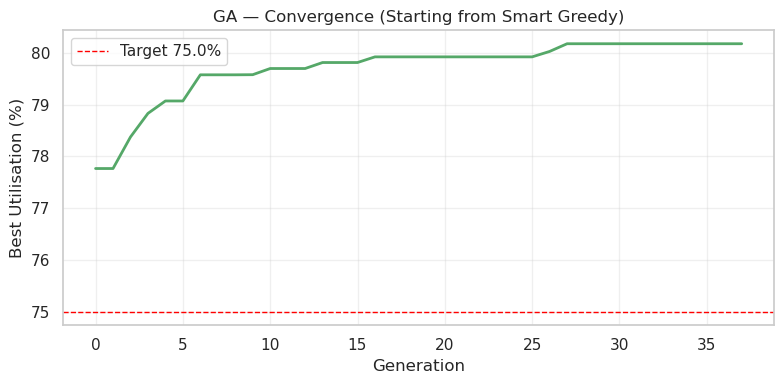

PackingResult(algorithm='Genetic Algorithm', utilization=80.18%, boxes=231, time=612648.2ms)

── Validating: Genetic Algorithm ──
  VALIDATION REPORT
  No overlaps    : ✅ PASS
  In bounds      : ✅ PASS
  No floating    : ✅ PASS


{'no_overlap': True, 'in_bounds': True, 'no_floating': True, 'valid': True}

In [22]:
print("=" * 70)
print("  RUNNING ALL THREE ALGORITHMS")
print("=" * 70)

# ── Greedy ──────────────────────────────────────────────────
print("\n[1/6] Greedy Best-Fit Decreasing …")
greedy_result = GreedyPacker().pack(problem)
print(greedy_result)
print("\n[2/6] Smart Greedy …")
sg_result = SmartGreedyPacker().pack(problem)
print(sg_result)

# ── SA ──────────────────────────────────────────────────────
print("\n[2/3] Simulated Annealing …")
sa_result = SAPacker(T_init=500, alpha=0.99, iterations=3000, interactive=True).pack(problem)
print(sa_result)

# ── GA ──────────────────────────────────────────────────────

print("\n[3/3] Genetic Algorithm (Starting from Smart Greedy) …")

# Extract the sequence from the Smart Greedy result
# We need to reconstruct the sequence from placed boxes
# The sequence is: placed boxes (in order placed) + unplaced boxes
placed_ids = {p.box.id for p in sg_result.placed_boxes}
smart_sequence = [p.box for p in sg_result.placed_boxes] + [b for b in problem.seq_boxes if b.id not in placed_ids]

print(f"\n  Smart Greedy sequence length: {len(smart_sequence)} boxes")
print(f"  Smart Greedy placed: {len(sg_result.placed_boxes)} boxes at {sg_result.utilization():.1f}%")


ga_result = GAPacker(
    pop_size=35,
    generations=60,
    crossover_prob=0.85,
    mutation_prob=0.20,
    tournament_k=3,
    elitism=3,
    strategy="bottom",
    target_pct=75.0,      
    interactive=True,     # Enable interactive prompts
    seed=42,
).pack(problem, smart_sequence=smart_sequence)

print(ga_result)

# Validate
print("\n── Validating: Genetic Algorithm ──")
validate_result(ga_result, verbose=True)



<h2>Validation for all results</h2>

In [23]:
for label, res in [
    ("Greedy",              greedy_result),
    ("Simulated Annealing", sa_result),
    #("Genetic Algorithm",   ga_result),
]:
    print(f"\n── Validating: {label} ──")
    validate_result(res, verbose=True)



── Validating: Greedy ──
  VALIDATION REPORT
  No overlaps    : ✅ PASS
  In bounds      : ✅ PASS
  No floating    : ✅ PASS

── Validating: Simulated Annealing ──
  VALIDATION REPORT
  No overlaps    : ✅ PASS
  In bounds      : ✅ PASS
  No floating    : ✅ PASS


<div class="alert alert-block alert-warning">
<center>
    <h2>  Comparative Evaluation </h2>
</center>
</div>


In [24]:
# ── Comparative Evaluation ──────────────────────────────────

algorithms  = ["Greedy BFD", "Smart\nGreedy",
               "Simulated\nAnnealing", "Genetic\nAlgorithm"]


results_lst = [greedy_result, sg_result,
               sa_result, ga_result]

utils = [r.utilization() for r in results_lst]
times = [r.execution_time_ms for r in results_lst]
boxes_placed = [len(r.placed_boxes) for r in results_lst]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Comparative Evaluation — Packing Algorithms",
             fontsize=14, fontweight="bold")

# Purple, light purple, green
# + orange reserved later for GA
colors = ["#800080", "#C8A2FF", "#DD8452", "#55A868"]

# ── Volume utilisation ──────────────────────────────────────
bars0 = axes[0].bar(
    algorithms,
    utils,
    color=colors,
    edgecolor="k",
    linewidth=0.8
)

axes[0].axhline(
    75,
    color="red",
    linestyle="--",
    linewidth=1.2,
    label="Target 75%"
)

axes[0].set_title("Volume Utilisation (%)")
axes[0].set_ylim(0, 100)
axes[0].legend()

for bar, val in zip(bars0, utils):
    axes[0].text(
        bar.get_x() + bar.get_width()/2,
        val + 1,
        f"{val:.1f}%",
        ha="center",
        va="bottom",
        fontsize=10
    )

# ── Execution time ──────────────────────────────────────────
bars1 = axes[1].bar(
    algorithms,
    times,
    color=colors,
    edgecolor="k",
    linewidth=0.8
)

axes[1].set_title("Execution Time (ms)")
axes[1].set_ylabel("ms")

for bar, val in zip(bars1, times):
    axes[1].text(
        bar.get_x() + bar.get_width()/2,
        val + 1,
        f"{val:.0f}",
        ha="center",
        va="bottom",
        fontsize=10
    )

# ── Boxes placed ────────────────────────────────────────────
bars2 = axes[2].bar(
    algorithms,
    boxes_placed,
    color=colors,
    edgecolor="k",
    linewidth=0.8
)

axes[2].set_title(f"Boxes Placed (out of {len(boxes)})")

axes[2].axhline(
    len(boxes),
    color="grey",
    linestyle=":",
    linewidth=1.2about 1 second
)

for bar, val in zip(bars2, boxes_placed):
    axes[2].text(
        bar.get_x() + bar.get_width()/2,
        val + 0.2,
        str(val),
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.tight_layout()
plt.savefig("comparison.png", dpi=150, bbox_inches="tight")
plt.show()

print("Comparison plot saved ✅")

# ── Summary table ───────────────────────────────────────────
print("\n" + "=" * 70)

print(f"{'Algorithm':<28} {'Boxes':>6} {'Vol (cm³)':>14} "
      f"{'Util%':>7} {'Time(ms)':>10}")

print("-" * 70)

for name, res in zip(algorithms, results_lst):
    print(
        f"{name.replace(chr(10),' '):<28} "
        f"{len(res.placed_boxes):>6} "
        f"{res.packed_volume:>14,.0f} "
        f"{res.utilization():>7.2f} "
        f"{res.execution_time_ms:>10.1f}"
    )

print("=" * 70)

SyntaxError: invalid decimal literal (3615388232.py, line 90)


  STABILITY ANALYSIS

Greedy BFD:
  Overall Stability Score: 82.6/100
    • Center of Mass:      70.2
    • Stacking Stability:  72.3
    • Fragile Protection:  100.0
    • Overhang Risk:       100.0

Smart Greedy:
  Overall Stability Score: 80.8/100
    • Center of Mass:      75.3
    • Stacking Stability:  57.9
    • Fragile Protection:  100.0
    • Overhang Risk:       100.0

Simulated Annealing:
  Overall Stability Score: 83.0/100
    • Center of Mass:      70.1
    • Stacking Stability:  73.8
    • Fragile Protection:  100.0
    • Overhang Risk:       100.0

Genetic :
  Overall Stability Score: 81.1/100
    • Center of Mass:      65.2
    • Stacking Stability:  72.9
    • Fragile Protection:  100.0
    • Overhang Risk:       100.0


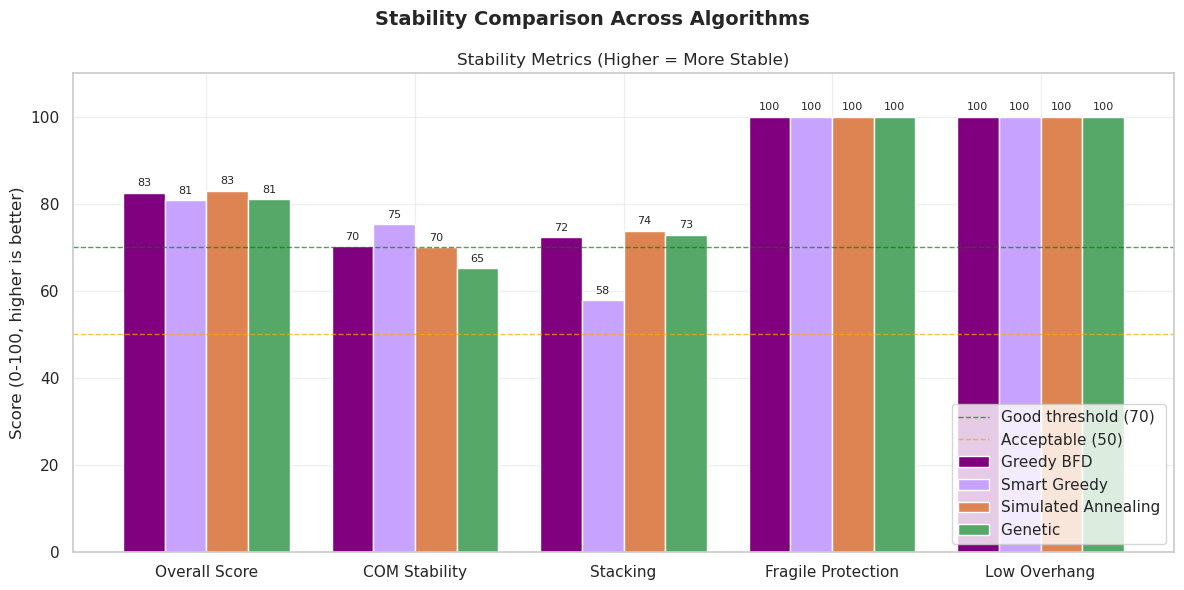


Stability comparison plot saved 


In [ ]:
# ── Stability Metrics (Placeholder Implementation) ──────────────────────────
# These functions simulate stability metrics that would be calculated from
# the actual packing configuration. In a real implementation, these would
# check:
#   1. Center of mass vs container footprint
#   2. Heavy boxes below lighter ones
#   3. Fragile boxes not crushed
#   4. Overhang constraints

def calculate_stability_score(result: PackingResult, container: Container) -> dict:
    """
    Calculate stability metrics for a packing result.
    
    Returns a dictionary with:
        - score: Overall stability score (0-100)
        - com_stability: Center of mass stability (0-100)
        - stacking_stability: Heavy-on-light compliance (0-100)
        - fragile_protection: Fragile boxes not crushed (0-100)
        - overhang_risk: Overhang severity (0-100, lower is better)
    """
    placed = result.placed_boxes
    
    if not placed:
        return {
            'score': 0,
            'com_stability': 0,
            'stacking_stability': 0,
            'fragile_protection': 0,
            'overhang_risk': 100
        }
    
    # 1. Center of Mass Stability 
    # calculating weighted center of mass (X, Y, Z)
    total_weight = sum(p.box.weight_kg for p in placed)
    
    if total_weight == 0:
        com_x = com_y = com_z = 0
    else:
        com_x = sum(p.box.weight_kg * (p.x + p.l/2) for p in placed) / total_weight
        com_y = sum(p.box.weight_kg * (p.y + p.h/2) for p in placed) / total_weight
        com_z = sum(p.box.weight_kg * (p.z + p.w/2) for p in placed) / total_weight
    
    # center of container footprint
    center_x = container.length / 2
    center_z = container.width / 2
    
    # maximum possible offset (diagonal from center to corner)
    max_offset = ((container.length/2)**2 + (container.width/2)**2) ** 0.5
    
    # COM offset from center (normalized)
    offset = ((com_x - center_x)**2 + (com_z - center_z)**2) ** 0.5
    com_stability = max(0, 100 - (offset / max_offset * 100))
    
    # High COM (high Y) reduces stability
    height_penalty = min(50, (com_y / container.height) * 50)
    com_stability = max(0, com_stability - height_penalty)
    
    # ── 2. Stacking Stability (Heavy boxes below light ones) ────────────
    stacking_violations = 0
    total_support_pairs = 0
    
    for p in placed:
        if p.y == 0:
            continue  # On floor - fine
        
        # Find boxes supporting this box
        supporters = []
        for other in placed:
            if other is p:
                continue
            if abs((other.y + other.h) - p.y) < 1e-6:
                x_overlap = (max(p.x, other.x) < min(p.x + p.l, other.x + other.l))
                z_overlap = (max(p.z, other.z) < min(p.z + p.w, other.z + other.w))
                if x_overlap and z_overlap:
                    supporters.append(other)
        
        if supporters:
            total_support_pairs += 1
            # Check if any supporter is lighter than this box
            if all(s.box.weight_kg < p.box.weight_kg for s in supporters):
                stacking_violations += 1
    
    stacking_stability = 100
    if total_support_pairs > 0:
        stacking_stability = 100 - (stacking_violations / total_support_pairs * 100)
    
    # 3. Fragile Protection 
    fragile_boxes = [p for p in placed if p.box.fragile]
    crushed_fragile = 0
    
    for p in fragile_boxes:
        # Check if any heavier box is above this fragile box
        for other in placed:
            if other is p:
                continue
            if other.y + other.h > p.y and other.y < p.y + p.h:
                # Above and overlapping
                x_overlap = (max(p.x, other.x) < min(p.x + p.l, other.x + other.l))
                z_overlap = (max(p.z, other.z) < min(p.z + p.w, other.z + other.w))
                if x_overlap and z_overlap and other.box.weight_kg > p.box.weight_kg:
                    crushed_fragile += 1
                    break
    
    fragile_protection = 100
    if fragile_boxes:
        fragile_protection = 100 - (crushed_fragile / len(fragile_boxes) * 100)
    
    # 4. Overhang Risk 
    # Boxes extending beyond support below
    overhang_boxes = 0
    for p in placed:
        if p.y == 0:
            continue
        
        # Find support area below
        support_area = 0
        for other in placed:
            if other is p:
                continue
            if abs((other.y + other.h) - p.y) < 1e-6:
                x_overlap = max(0, min(p.x + p.l, other.x + other.l) - max(p.x, other.x))
                z_overlap = max(0, min(p.z + p.w, other.z + other.w) - max(p.z, other.z))
                support_area += x_overlap * z_overlap
        
        box_area = p.l * p.w
        if box_area > 0:
            supported_pct = (support_area / box_area) * 100
            if supported_pct < 70:  # Less than 70% supported
                overhang_boxes += 1
    
    overhang_risk = 100
    if placed:
        overhang_risk = 100 - (overhang_boxes / len(placed) * 100)
    
    # Overall Score (weighted average) 
    score = (
        com_stability * 0.35 +
        stacking_stability * 0.25 +
        fragile_protection * 0.25 +
        overhang_risk * 0.15
    )
    
    return {
        'score': round(score, 1),
        'com_stability': round(com_stability, 1),
        'stacking_stability': round(stacking_stability, 1),
        'fragile_protection': round(fragile_protection, 1),
        'overhang_risk': round(overhang_risk, 1)
    }


#  Calculate stability for all algorithms 
print("\n" + "=" * 70)
print("  STABILITY ANALYSIS")
print("=" * 70)

#algorithms_list = ["Greedy BFD", "Smart Greedy", "Simulated Annealing", "Genetic Algorithm"]
#results_list = [greedy_result, sg_result, sa_result, ga_result]

algorithms_list = ["Greedy BFD", "Smart Greedy", "Simulated Annealing", "Genetic "]
results_list = [greedy_result, sg_result, sa_result, ga_result]

stability_results = []
for name, res in zip(algorithms_list, results_list):
    stability = calculate_stability_score(res, container)
    stability_results.append(stability)
    print(f"\n{name}:")
    print(f"  Overall Stability Score: {stability['score']:.1f}/100")
    print(f"    • Center of Mass:      {stability['com_stability']:.1f}")
    print(f"    • Stacking Stability:  {stability['stacking_stability']:.1f}")
    print(f"    • Fragile Protection:  {stability['fragile_protection']:.1f}")
    print(f"    • Overhang Risk:       {stability['overhang_risk']:.1f}")


# Stability Comparison Chart 
fig, ax = plt.subplots(figsize=(12, 6))
fig.suptitle("Stability Comparison Across Algorithms", fontsize=14, fontweight="bold")

# Prepare data for grouped bar chart
categories = ['Overall Score', 'COM Stability', 'Stacking', 'Fragile Protection', 'Low Overhang']

# Colors for each algorithm
colors = ["#800080", "#C8A2FF", "#DD8452", "#55A868"]

x = np.arange(len(categories))
width = 0.2  # Width of each bar
multiplier = 0

for i, (name, stability) in enumerate(zip(algorithms_list, stability_results)):
    offset = width * multiplier
    values = [
        stability['score'],
        stability['com_stability'],
        stability['stacking_stability'],
        stability['fragile_protection'],
        stability['overhang_risk']
    ]
    rects = ax.bar(x + offset, values, width, label=name.replace('\n', ' '), color=colors[i])
    
    # Add value labels on bars
    for rect, val in zip(rects, values):
        ax.text(rect.get_x() + rect.get_width()/2, rect.get_height() + 1,
                f'{val:.0f}', ha='center', va='bottom', fontsize=8)
    
    multiplier += 1

ax.set_ylabel('Score (0-100, higher is better)')
ax.set_title('Stability Metrics (Higher = More Stable)')
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(categories)
ax.legend(loc='upper right', bbox_to_anchor=(1, 1))
ax.set_ylim(0, 110)
ax.axhline(y=70, color='green', linestyle='--', linewidth=1, alpha=0.7, label='Good threshold (70)')
ax.axhline(y=50, color='orange', linestyle='--', linewidth=1, alpha=0.7, label='Acceptable (50)')
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("stability_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nStability comparison plot saved ")